In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score

In [2]:
df = pd.read_csv('../data/processed/model_dataset_v1.csv')
print(df.shape)
print(df.columns)
print(df.isna().sum())
df.head()

(4096, 30)
Index(['game_id', 'season', 'week', 'gameday', 'game_type', 'home_team',
       'away_team', 'neutral_site', 'home_rest_days', 'away_rest_days',
       'home_win', 'home_field', 'home_pregame_off_epa',
       'home_pregame_off_success_rate', 'home_pregame_pass_epa',
       'home_pregame_rush_epa', 'home_pregame_def_epa_allowed',
       'home_pregame_def_success_rate_allowed', 'home_pregame_ppg',
       'home_pregame_ppg_allowed', 'home_pregame_win_pct',
       'away_pregame_off_epa', 'away_pregame_off_success_rate',
       'away_pregame_pass_epa', 'away_pregame_rush_epa',
       'away_pregame_def_epa_allowed', 'away_pregame_def_success_rate_allowed',
       'away_pregame_ppg', 'away_pregame_ppg_allowed', 'away_pregame_win_pct'],
      dtype='str')
game_id                                  0
season                                   0
week                                     0
gameday                                  0
game_type                                0
home_team       

,game_id,season,week,gameday,game_type,home_team,away_team,neutral_site,home_rest_days,away_rest_days,...,home_pregame_win_pct,away_pregame_off_epa,away_pregame_off_success_rate,away_pregame_pass_epa,away_pregame_rush_epa,away_pregame_def_epa_allowed,away_pregame_def_success_rate_allowed,away_pregame_ppg,away_pregame_ppg_allowed,away_pregame_win_pct
0,2010_02_ARI_ATL,2010,2,2010-09-19,REG,ATL,ARI,0,7,7,...,0.0,-0.136437,0.352941,0.092355,-0.614819,-0.195926,0.358025,17.0,13.0,1.0
1,2010_02_BAL_CIN,2010,2,2010-09-19,REG,CIN,BAL,0,7,6,...,0.0,-0.114943,0.395062,0.095338,-0.391312,-0.411004,0.311111,10.0,9.0,1.0
2,2010_02_BUF_GB,2010,2,2010-09-19,REG,GB,BUF,0,7,7,...,1.0,-0.231829,0.309091,-0.221807,-0.258552,-0.009411,0.418919,10.0,15.0,0.0
3,2010_02_CHI_DAL,2010,2,2010-09-19,REG,DAL,CHI,0,7,7,...,0.0,-0.151665,0.447368,-0.030265,-0.371984,-0.300751,0.321429,19.0,14.0,1.0
4,2010_02_HOU_WAS,2010,2,2010-09-19,REG,WAS,HOU,0,7,7,...,1.0,0.260859,0.610169,-0.032805,0.411455,0.174313,0.500000,34.0,24.0,1.0


In [3]:
diff_pairs = {
    "off_epa_diff": (
        "home_pregame_off_epa",
        "away_pregame_off_epa"
    ),
    "off_success_rate_diff": (
        "home_pregame_off_success_rate",
        "away_pregame_off_success_rate"
    ),
    "pass_epa_diff": (
        "home_pregame_pass_epa",
        "away_pregame_pass_epa"
    ),
    "rush_epa_diff": (
        "home_pregame_rush_epa",
        "away_pregame_rush_epa"
    ),
    "def_epa_allowed_diff": (
        "home_pregame_def_epa_allowed",
        "away_pregame_def_epa_allowed"
    ),
    "def_success_rate_allowed_diff": (
        "home_pregame_def_success_rate_allowed",
        "away_pregame_def_success_rate_allowed"
    ),
    "ppg_diff": (
        "home_pregame_ppg",
        "away_pregame_ppg"
    ),
    "ppg_allowed_diff": (
        "home_pregame_ppg_allowed",
        "away_pregame_ppg_allowed"
    ),
    "win_pct_diff": (
        "home_pregame_win_pct",
        "away_pregame_win_pct"
    ),
    "rest_days_diff": (
        "home_rest_days",
        "away_rest_days"
    )
}

In [4]:
for new_col, (home_col, away_col) in diff_pairs.items():
    df[new_col] = df[home_col] - df[away_col]

In [5]:
features = [
    'home_pregame_off_epa',
    'home_pregame_off_success_rate',
    'home_pregame_pass_epa',
    'home_pregame_rush_epa', 
    'home_pregame_def_epa_allowed',
    'home_pregame_def_success_rate_allowed', 
    'home_pregame_ppg',
    'home_pregame_ppg_allowed', 
    'home_pregame_win_pct',
    'home_rest_days',
    'away_pregame_off_epa', 
    'away_pregame_off_success_rate',
    'away_pregame_pass_epa',
    'away_pregame_rush_epa',
    'away_pregame_def_epa_allowed', 
    'away_pregame_def_success_rate_allowed',
    'away_pregame_ppg', 
    'away_pregame_ppg_allowed', 
    'away_pregame_win_pct',
    'away_rest_days',
]

In [6]:
diff_features = [
    "off_epa_diff",
    "off_success_rate_diff",
    "pass_epa_diff",
    "rush_epa_diff",
    "def_epa_allowed_diff",
    "def_success_rate_allowed_diff",
    "ppg_diff",
    "ppg_allowed_diff",
    "win_pct_diff",
    "rest_days_diff",
]

In [7]:
train = df[df['season'] <= 2023].copy()
val = df[df['season'] == 2024].copy()
test = df[df['season'] == 2025].copy()

In [8]:
len(train), len(val), len(test)

(3559, 269, 268)

In [9]:
y_train = train['home_win']
y_val = val['home_win']
y_test = test['home_win']

In [10]:
home_win_rate = y_train.mean()

baseline_prob = np.full(
    len(val),
    home_win_rate
)
baseline_pred = (baseline_prob >= 0.5).astype(int)

In [11]:
baseline_accuracy = accuracy_score(y_val, baseline_pred)
baseline_logloss = log_loss(y_val, baseline_prob)
baseline_brier = brier_score_loss(y_val, baseline_prob)
baseline_auc = roc_auc_score(y_val, baseline_prob)

In [12]:
x_train = train[features]
x_val = val[features]
x_test = test[features]

In [13]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

In [14]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['home_pregame_off_epa','home_pregame_off_success_rate', 'home_pregame_pass_epa',...,'away_pregame_ppg_allowed', 'away_pregame_win_pct','away_rest_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
val_prob = model.predict_proba(x_val)[:, 1]
val_pred = (val_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_val, val_pred)
logloss = log_loss(y_val, val_prob)
brier = brier_score_loss(y_val, val_prob)
auc = roc_auc_score(y_val, val_prob)

In [16]:
x_train_diff = train[diff_features]
x_val_diff = val[diff_features]
x_test_diff = test[diff_features]

In [17]:
diff_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

In [18]:
diff_model.fit(x_train_diff, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['off_epa_diff','off_success_rate_diff','pass_epa_diff',..., 'ppg_allowed_diff','win_pct_diff','rest_days_diff']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [19]:
diff_val_prob = diff_model.predict_proba(x_val_diff)[:, 1]
diff_val_pred = (diff_val_prob >= 0.5).astype(int)

diff_accuracy = accuracy_score(y_val, diff_val_pred)
diff_logloss = log_loss(y_val, diff_val_prob)
diff_brier = brier_score_loss(y_val, diff_val_prob)
diff_auc = roc_auc_score(y_val, diff_val_prob)

In [20]:
model_results = pd.DataFrame({
    'model': ['baseline', 'logistic_regression', 'logistic_regression_diff'],
    'accuracy': [baseline_accuracy, accuracy, diff_accuracy],
    'log_loss': [baseline_logloss, logloss, diff_logloss],
    'brier_score': [baseline_brier, brier, diff_brier],
    'roc_auc': [baseline_auc, auc, diff_auc]
})
model_results.head()

,model,accuracy,log_loss,brier_score,roc_auc
0,baseline,0.539033,0.691083,0.248964,0.500000
1,logistic_regression,0.672862,0.622797,0.215553,0.727586
2,logistic_regression_diff,0.665428,0.628025,0.217791,0.716741


In [21]:
results = val[['season', 'week', 'home_team', 'away_team', 'home_win']].copy()
results['home_win_prob_model1'] = val_prob
results['home_win_prob_model2'] = diff_val_prob
results['predicted_home_win'] = val_pred
results['predicted_home_win_model2'] = diff_val_pred
results.sort_values("home_win_prob_model1", ascending=False).head()

,season,week,home_team,away_team,home_win,home_win_prob_model1,home_win_prob_model2,predicted_home_win,predicted_home_win_model2
3579,2024,3,TB,DEN,0,0.885063,0.872807,1,1
3577,2024,3,LV,CAR,0,0.874011,0.887761,1,1
3612,2024,5,WAS,CLE,1,0.865558,0.862928,1,1
3636,2024,7,WAS,CAR,1,0.851996,0.865386,1,1
3800,2024,18,BAL,CLE,1,0.840572,0.845454,1,1


In [22]:
logreg = model.named_steps['logreg']
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_df.head(20)

,feature,coefficient
0,home_pregame_off_epa,0.565353
2,home_pregame_pass_epa,-0.379144
7,home_pregame_ppg_allowed,-0.264466
11,away_pregame_off_success_rate,-0.219844
3,home_pregame_rush_epa,-0.161081
1,home_pregame_off_success_rate,0.157757
16,away_pregame_ppg,-0.131183
17,away_pregame_ppg_allowed,0.104479
10,away_pregame_off_epa,-0.090304
6,home_pregame_ppg,0.080593


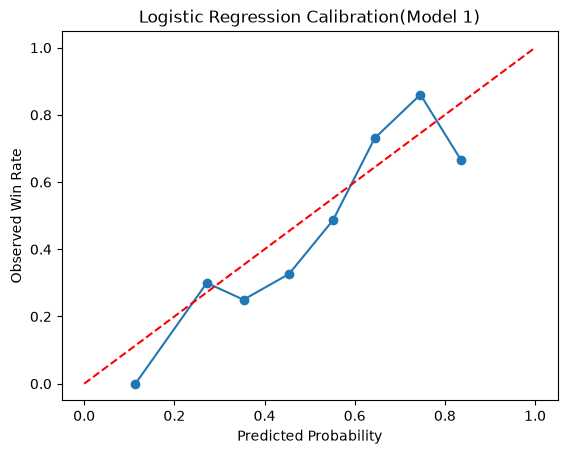

In [23]:
prob_true, prob_pred = calibration_curve(y_val, val_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Win Rate')
plt.title('Logistic Regression Calibration(Model 1)')
plt.show()

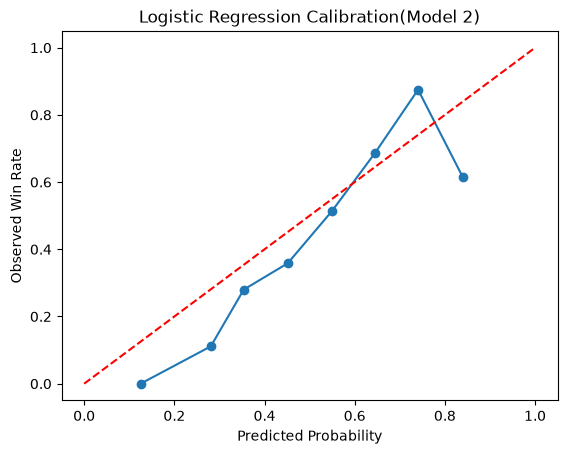

In [24]:
prob_true, prob_pred = calibration_curve(y_val, diff_val_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Win Rate')
plt.title('Logistic Regression Calibration(Model 2)')
plt.show()

In [25]:
x_train.corr()

,home_pregame_off_epa,home_pregame_off_success_rate,home_pregame_pass_epa,home_pregame_rush_epa,home_pregame_def_epa_allowed,home_pregame_def_success_rate_allowed,home_pregame_ppg,home_pregame_ppg_allowed,home_pregame_win_pct,home_rest_days,away_pregame_off_epa,away_pregame_off_success_rate,away_pregame_pass_epa,away_pregame_rush_epa,away_pregame_def_epa_allowed,away_pregame_def_success_rate_allowed,away_pregame_ppg,away_pregame_ppg_allowed,away_pregame_win_pct,away_rest_days
home_pregame_off_epa,1.000000,0.812182,0.936336,0.503241,0.049729,0.215589,0.844467,-0.156799,0.579132,0.049618,0.072546,0.068314,0.062832,0.035930,-0.015106,0.030639,0.056457,-0.023930,0.056342,0.030572
home_pregame_off_success_rate,0.812182,1.000000,0.710908,0.476949,0.148527,0.256598,0.677799,-0.009258,0.403821,0.051736,0.067029,0.080076,0.058901,0.028528,-0.002696,0.042764,0.063556,0.010760,0.031830,0.037295
home_pregame_pass_epa,0.936336,0.710908,1.000000,0.227826,-0.027018,0.153286,0.803491,-0.209337,0.593689,0.042990,0.070793,0.052504,0.067331,0.025020,-0.006106,0.030831,0.049206,-0.017118,0.057197,0.025346
home_pregame_rush_epa,0.503241,0.476949,0.227826,1.000000,0.051595,0.129538,0.417099,-0.067280,0.266568,0.036663,0.017813,0.057419,-0.000944,0.036663,-0.011130,0.019037,0.013859,-0.012262,0.007037,0.012086
home_pregame_def_epa_allowed,0.049729,0.148527,-0.027018,0.051595,1.000000,0.722111,-0.144786,0.791764,-0.480081,-0.021369,0.000919,0.010093,0.006432,-0.015552,0.022484,0.033837,0.009487,0.020382,-0.018277,-0.009577
home_pregame_def_success_rate_allowed,0.215589,0.256598,0.153286,0.129538,0.722111,1.000000,0.067966,0.524257,-0.214049,-0.013019,0.021406,0.048201,0.017949,0.010829,0.014991,0.046168,0.032475,0.021917,-0.027965,-0.011396
home_pregame_ppg,0.844467,0.677799,0.803491,0.417099,-0.144786,0.067966,1.000000,-0.101701,0.638055,0.048254,0.074931,0.068027,0.059170,0.051051,-0.007105,0.021987,0.052160,-0.008154,0.048957,0.026548
home_pregame_ppg_allowed,-0.156799,-0.009258,-0.209337,-0.067280,0.791764,0.524257,-0.101701,1.000000,-0.574101,-0.032413,0.004240,0.015385,0.006484,-0.006090,0.033928,0.031713,0.009938,0.042775,-0.028912,-0.008437
home_pregame_win_pct,0.579132,0.403821,0.593689,0.266568,-0.480081,-0.214049,0.638055,-0.574101,1.000000,0.046733,0.041073,0.042289,0.025435,0.033958,-0.018146,-0.013906,0.014532,-0.037942,0.036583,0.020805
home_rest_days,0.049618,0.051736,0.042990,0.036663,-0.021369,-0.013019,0.048254,-0.032413,0.046733,1.000000,0.019978,0.025039,0.016637,0.020769,-0.018692,-0.019746,0.003933,-0.020767,0.016416,0.254096


In [26]:
x_train_diff.corr()

,off_epa_diff,off_success_rate_diff,pass_epa_diff,rush_epa_diff,def_epa_allowed_diff,def_success_rate_allowed_diff,ppg_diff,ppg_allowed_diff,win_pct_diff,rest_days_diff
off_epa_diff,1.000000,0.795589,0.930226,0.503768,0.064733,0.201002,0.822228,-0.157102,0.557922,0.011611
off_success_rate_diff,0.795589,1.000000,0.693518,0.453335,0.157792,0.226343,0.639177,-0.019770,0.379008,-0.004297
pass_epa_diff,0.930226,0.693518,1.000000,0.217382,-0.028972,0.127658,0.788561,-0.218311,0.579956,0.010847
rush_epa_diff,0.503768,0.453335,0.217382,1.000000,0.081438,0.133769,0.386991,-0.058997,0.244445,0.010814
def_epa_allowed_diff,0.064733,0.157792,-0.028972,0.081438,1.000000,0.737479,-0.142357,0.790356,-0.480373,0.007952
def_success_rate_allowed_diff,0.201002,0.226343,0.127658,0.133769,0.737479,1.000000,0.046065,0.545545,-0.223568,0.023831
ppg_diff,0.822228,0.639177,0.788561,0.386991,-0.142357,0.046065,1.000000,-0.097065,0.623977,0.026705
ppg_allowed_diff,-0.157102,-0.019770,-0.218311,-0.058997,0.790356,0.545545,-0.097065,1.000000,-0.569344,0.005298
win_pct_diff,0.557922,0.379008,0.579956,0.244445,-0.480373,-0.223568,0.623977,-0.569344,1.000000,0.015057
rest_days_diff,0.011611,-0.004297,0.010847,0.010814,0.007952,0.023831,0.026705,0.005298,0.015057,1.000000


In [27]:
test_prob = model.predict_proba(x_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, test_pred)
test_logloss = log_loss(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)
test_auc = roc_auc_score(y_test, test_prob)

In [28]:
test2_prob = diff_model.predict_proba(x_test_diff)[:, 1]
test2_pred = (test2_prob >= 0.5).astype(int)

test2_accuracy = accuracy_score(y_test, test2_pred)
test2_logloss = log_loss(y_test, test2_prob)
test2_brier = brier_score_loss(y_test, test2_prob)
test2_auc = roc_auc_score(y_test, test2_prob)

In [29]:
test_results = pd.DataFrame({
    'model': ['test_model1', 'test_model2'],
    'accuracy': [test_accuracy, test2_accuracy],
    'log_loss': [test_logloss, test2_logloss],
    'brier_score': [test_brier, test2_brier],
    'roc_auc': [test_auc, test2_auc]
})
test_results.head()

,model,accuracy,log_loss,brier_score,roc_auc
0,test_model1,0.615672,0.635465,0.223415,0.680783
1,test_model2,0.582090,0.640638,0.225982,0.669930


In [30]:
model_path = Path('../models/logistic_regression_v1.joblib')

artifact = {
    'model': model,
    'features': features,
    'target': 'home_win',
    'decision_threshold': 0.5,
    'training_seasons': '2010-2023',
    'validation_season': 2024,
    'test_season': 2025,
}

joblib.dump(artifact, model_path)

print(f'Saved model to: {model_path.resolve()}')

Saved model to: C:\Coding Projects\NFL-2026-Machine-Learning-Project\models\logistic_regression_v1.joblib
